In [1]:
%load_ext autoreload
%autoreload 2

from noise import * 
from pathlib import Path 
import json
from data import *
from trackers import *
from main import *

from networks.conditioning import *

import matplotlib.pyplot as plt
import numpy as np

In [2]:
def load_args(name, step="last", log=True, dataloaders=False):
    """ Load an experiment with a given name. step can be an integer, "best", or "last" (default). """
    exp_dir = Path("models") / name

    with open(exp_dir / "args.json") as f:
        args_dict = json.load(f)

    return args_dict


def load_exp(name, step="last", log=True, dataloaders=False):
    """ Load an experiment with a given name. step can be an integer, "best", or "last" (default). """
    exp_dir = Path("models") / name

    with open(exp_dir / "args.json") as f:
        args_dict = json.load(f)

    args_dict["size_network"] = "large"

    ctx = TrainingContext(**args_dict, step=step, key_remap=None, seed=None, dataloaders=dataloaders, writer=False)
    if log:
        print(f"{name}: retrieved model at step {ctx.step}")

    # Disable DataParallel (needed for Hessian computation)
    # ctx.model.network = ctx.model.network.module

    # Put in eval mode and disable gradients with respect to all parameters.
    ctx.model.eval()
    for p in ctx.model.parameters():
        p.requires_grad = False

    # Normalize energies.
    # ctx.network.network.log_normalization_constant = ctx.test_perf.log_normalization_constant

    return ctx

In [4]:
torch.set_default_dtype(torch.float32)
    # torch.set_printoptions(precision=10, sci_mode=False)
step = "last"
step_dual = step
args = load_args(f"multigpu/all_together/energy_song_dual_truncatedFreq_celeba", step = step)
# args = load_args("multigpu/combined_cov_tworandvars/energy_songWavelet_anisoEmb_groupNorm_lambda1_lr1.5e-4_lrdecay15000_1000warmup_d2", step = "last")
ctxs = {
    "energy-reg-d2": load_exp(f"multigpu/all_together/energy_song_dual_truncatedFreq_celeba", step = step_dual),
    # "energy-non-reg": load_exp(f"multigpu/all_together/energy_song_dual_truncatedFreq_imagenet", step = step_dual),
    "energy-non-reg": load_exp("multigpu/all_together/energy_song_single_truncatedFreq_celeba", step = step),
}

default_ctx = ctxs["energy-reg-d2"]
device = default_ctx.device
dataset_info = default_ctx.dataset_info
d = dataset_info.dimension


# Load data
test_batch_size = 16
CHW = 3 * 64 * 64
H = 64
seed = 20
train_dataloader, test_dataloader, dataset_info = load_data(
    dataset=args["dataset"], spatial_size=args["spatial_size"], grayscale=args["grayscale"], horizontal_flip=False, data_subset=eval(args["data_subset"]),
    train_batch_size=test_batch_size, test_batch_size=test_batch_size, num_workers=args["num_workers"], seed=seed
)

images = next(iter(test_dataloader))  # load for testing things.

shape = (images[0].shape[0], CHW)

time_tracker: TimeTracker = TimeTracker()
time_tracker.switch("initialization")

False
[EMA LOAD] 'ema' NOT in checkpoint (use_ema=True)
multigpu/all_together/energy_song_dual_truncatedFreq_celeba: retrieved model at step 400000
False
[EMA LOAD] 'ema' NOT in checkpoint (use_ema=True)
multigpu/all_together/energy_song_single_truncatedFreq_celeba: retrieved model at step 240000
Loading CelebA from train_64x64.pt...
✓ Loaded 182637 images with shape (182637, 64, 64, 3)
Loading CelebA from test_64x64.pt...
✓ Loaded 19962 images with shape (19962, 64, 64, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.023499072..1.1304737].


14
3 0 tensor(-3., device='cuda:0') tensor(30., device='cuda:0') 9.119951743088277 1
3 0 tensor(-3., device='cuda:0') tensor(30., device='cuda:0') 9.286873623417327 2


KeyboardInterrupt: 

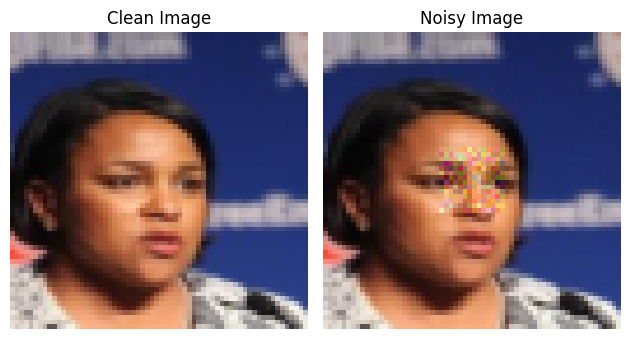

In [6]:
min_noise_level: NoiseLevel = NoiseLevel.from_unit(dataset_info=dataset_info, **args["min_noise_level"]) # This calls denoising error
max_noise_level: NoiseLevel = NoiseLevel.from_unit(dataset_info=dataset_info, **args["max_noise_level"])
noise_level_sampler: NoiseLevelSampler = eval(args["noise_level_sampler"])(min=min_noise_level, max=max_noise_level)

delta_box_reg = np.zeros(H)
delta_box_non_reg = np.zeros(H)
idx_img = 14
ii = 0
min_energy_reg_list = []
min_energy_non_reg_list = []
for box in [14]:
    psnr = -30
    box_size = box
    noise_level = 0.1**2 #3
    psnr_2 = 60
    noise_level_2 = 1e-4**2  #1**2 #1#1e-7**2 #DenoisingError(dataset_info=dataset_info, psnr=psnr_2).to_noise_level().variance # 1
    inp_mask_type = "box"
    H_deg = spatial_corr_covariance_testing(spatial_size=H, box_size=box_size, var_box=noise_level * 1, device=device, var_clean = noise_level_2 * 1, inp_mask_type=inp_mask_type, half_box_size = box_size)
    sigma_noise = 1e-3 #1e-9
    
    # y = H_deg.apply_power(images[0].cuda(), p = 1) + sigma_noise * torch.randn_like(images[0]).cuda()
    y = images[0].cuda() + H_deg.apply_power(torch.randn_like(images[0]).cuda(), p = 0.5)
    
    print(box_size)
    fig, ax = plt.subplots(1, 2)
    ax[0].set_title('Clean Image')
    ax[1].set_title('Noisy Image')
    ax[0].imshow(images[0][idx_img,:,:,:].permute(1,2,0).cpu().numpy())
    ax[1].imshow(y[idx_img,:,:,:].permute(1,2,0).cpu().numpy())
    ax[0].axis("off")
    ax[1].axis("off")
    plt.tight_layout()
    fig.savefig("i.pdf", bbox_inches='tight', pad_inches=0.05)
    
    num_variances = 4
    psnr_min = -1 #0
    psnr_max = -3 #-35
    psnrs = torch.linspace(psnr_min, psnr_max, num_variances , device=default_ctx.device)  # (L,), steps of 7.5dB
    noise_levels_inv = 1e9 #1e9
    noise_levels_2_inv = 0.1e-2#1e-3**2 #1e-3**2 #1
    noise_levels = DenoisingError(dataset_info=default_ctx.dataset_info, psnr=psnrs).to_noise_level().variance  # (L,)#1e3 #0.9e-3
    
    psnr_min = 30 #20 for 10 to 20 
    psnr_max = -15 #-15 #-15 for 10 to 20
    psnrs = torch.linspace(psnr_min, psnr_max, num_variances , device=default_ctx.device)  # (L,), steps of 7.5dB
    noise_levels_2 =  DenoisingError(dataset_info=default_ctx.dataset_info, psnr=psnrs).to_noise_level().variance #10e-1 # 0.1e-1 for box from 10 to 20
    sigma_noise_2 = 1 #sigma_noise**2
    output_reg_d2 =  torch.zeros(num_variances, num_variances)
    output_non_reg_d2 =  torch.zeros(num_variances, num_variances)
    min_energy_reg = np.zeros(H)
    min_energy_non_reg = np.zeros(H)
    estimated_var_reg = np.zeros(H)
    estimated_var_non_reg = np.zeros(H)
    
    box_idx = 0
    start_point = 1
    end_point = 64
    for box_inner in range(start_point, end_point):
        for idx in range(num_variances):
            for idx_inner in range(num_variances):
                H_deg_inv = [spatial_corr_covariance_testing(spatial_size=H, box_size=box_inner, var_box=noise_levels_inv, device=device, var_clean = noise_levels_2_inv, inp_mask_type=inp_mask_type, half_box_size = box_inner)]
                y_hat = torch.clamp(y, 0, 1)
                covariance = [spatial_corr_covariance_testing(spatial_size=H, box_size=box_inner, var_box=noise_levels[idx] * sigma_noise_2, device=device, var_clean = noise_levels_2[idx_inner], inp_mask_type=inp_mask_type, half_box_size = box_inner)]
                noise_level = NoiseLevel(variance=(noise_levels_inv))                
                input = ModelInput(noisy=y_hat[idx_img:idx_img+1], noise_level=noise_level, covariance=covariance)
                model_output_reg = ctxs['energy-reg-d2'].model.forward(input, create_graph = False)
                model_output_non_reg = ctxs['energy-non-reg'].model.forward(input, create_graph = False)
                output_reg_d2[idx, idx_inner] = model_output_reg.energy  # log p(x_old)
                output_non_reg_d2[idx, idx_inner] = model_output_non_reg.energy  # log p(x_old)

        # 1. Find the minimum value in the entire tensor
        min_val = torch.min(output_reg_d2)
        
        # 2. Find the indices where the tensor equals that minimum
        # This returns a tuple of tensors (row_indices, col_indices)
        coords = torch.where(output_reg_d2 == min_val)
        
        # 3. Extract x (row) and y (column)
        # If there are multiple minimums, [0] takes the first one
        x_pos = coords[0][0].item()
        y_pos = coords[1][0].item()
        # print(output_reg_d2)
        min_energy_reg[box_inner] = np.min(output_reg_d2.detach().cpu().numpy())
        # print( min_energy_reg[box_inner])
        print(x_pos, y_pos, -10 * torch.log10(noise_levels[x_pos]), -10 * torch.log10(noise_levels_2[y_pos]), np.log(-min_energy_reg[box_inner]), box_inner)
        min_energy_non_reg[box_inner] = np.min(output_non_reg_d2.detach().cpu().numpy())
        # print(np.argmin(output_reg_d2.detach().cpu().numpy(), axis = 0), np.argmin(output_reg_d2.detach().cpu().numpy(), axis = 1))
        # print(min_energy)
        # estimated_var_reg[box_inner] = noise_levels[np.argmin(output_reg_d2.detach().cpu().numpy()).item()].cpu().numpy()
        # estimated_var_non_reg[box_inner] = noise_levels[np.argmin(output_non_reg_d2.detach().cpu().numpy()).item()].cpu().numpy()

        # box_idx = box_idx + 1
        
    print(box, np.argmin(min_energy_reg),np.min(min_energy_reg), np.argmin(min_energy_non_reg)) #, np.argmin(min_energy[5:60]))
    
    
    # box_idx = 0
    # for box_inner in range(5, 60):
    #     H_deg_inv = [spatial_corr_covariance_testing(spatial_size=H, box_size=box_inner, var_box=noise_levels_inv, device=device, var_clean = noise_levels_2_inv, inp_mask_type=inp_mask_type, half_box_size = box_inner)]
    #     # output_reg_d2[idx] = ctxs['energy-reg-d2'].network(y[0:1,:,:,:], covariance.get_matrix()[None,None,:,:], type_cov_list = torch.tensor(0))
    #     y_hat = torch.clamp(H_deg_inv[0].apply_power(y, p = 1), 0, 1)
    #     # plt.imshow(y_hat[0].cpu().permute(1,2,0).numpy())
    #     # plt.show()
    #     covariance = [spatial_corr_covariance_testing(spatial_size=H, box_size=box_inner, var_box=noise_levels * sigma_noise_2, device=device, var_clean = noise_levels_2, inp_mask_type=inp_mask_type, half_box_size = box_inner)]
    #     # print(covariance[0].get_matrix())
    #     noise_level = NoiseLevel(variance=(noise_levels_inv))                
    #     input = ModelInput(noisy=y_hat[idx_img:idx_img+1], noise_level=noise_level, covariance=covariance)
    #     model_output_reg = ctxs['energy-reg-d2'].model.forward(input, create_graph = False)
    #     model_output_non_reg = ctxs['energy-non-reg'].model.forward(input, create_graph = False)
    #     min_energy_reg[box_inner] = model_output_reg.energy.detach().cpu().numpy()
    #     min_energy_non_reg[box_inner] = model_output_non_reg.energy.detach().cpu().numpy()
            
    # print(box, np.argmin(min_energy_reg),np.min(min_energy_reg), np.argmin(min_energy_non_reg)) #, np.argmin(min_energy[5:60]))

    delta_box_reg[box] = (np.argmin(min_energy_reg[start_point:end_point]) + start_point) - box
    delta_box_non_reg[box] = (np.argmin(min_energy_non_reg[start_point:end_point]) + start_point) - box
    print(delta_box_reg, delta_box_non_reg)

    start_point = 1
    plt.figure(ii)
    plt.plot(np.arange(0, 64 - start_point) + start_point, min_energy_reg[start_point:64], '-o', color = 'red', label = f'Dual - Box {box}')
    plt.plot(np.arange(0, 64 - start_point) + start_point, min_energy_non_reg[start_point:64], '-o', color = 'blue', label = f'Single - Box {box}')
    plt.axvline(x = box_size)
    plt.axvline(x = np.argmin(min_energy_reg[start_point:64]) + start_point, color = 'red', label = f"Dual - Estimated {np.argmin(min_energy_reg[start_point:64]) + start_point}")
    plt.axvline(x = np.argmin(min_energy_non_reg[start_point:64]) + start_point, color = 'blue', label = f"Single - Estimated {np.argmin(min_energy_non_reg[start_point:64]) + start_point}")
    plt.legend()
    plt.xlabel(r"Box size $d$")
    plt.ylabel(r"Unnormalized $U_{\theta}$")
    ii = ii + 1

    min_energy_reg_list.append(min_energy_reg)
    min_energy_non_reg_list.append(min_energy_non_reg)
# torch.save(delta_box, f"box_difference_{noise_levels}_mask_true.pt")
    # -12763.53

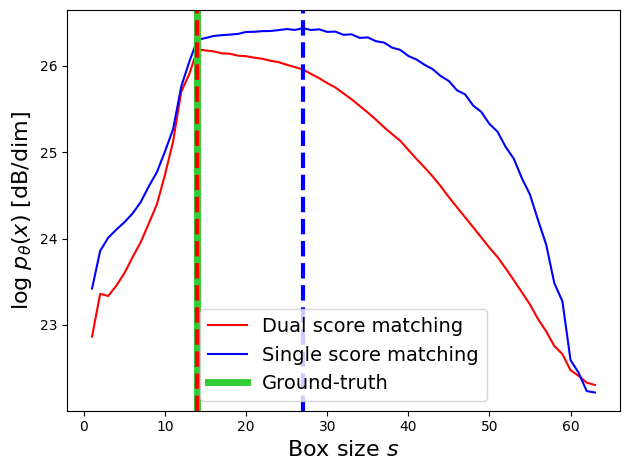

In [ ]:
constant = 59882.5938
start_point = 1
plt.figure(ii)

plt.plot(np.arange(0, 64 - start_point) + start_point, (10.0 / np.log(10)) * ((-min_energy_reg[start_point:64]+ constant) / CHW), '-', color = 'red', label = f'Dual score matching')
plt.plot(np.arange(0, 64 - start_point) + start_point, (10.0 / np.log(10)) * ((-min_energy_non_reg[start_point:64]+ constant) / CHW), '-', color = 'blue', label = f'Single score matching')
plt.axvline(x = box_size, linewidth = 5, label = 'Ground-truth', color = 'limegreen')
plt.axvline(x = np.argmin(min_energy_reg[start_point:64]) + start_point, linewidth = 3, linestyle='--', color = 'red')
plt.axvline(x = np.argmin(min_energy_non_reg[start_point:64]) + start_point, linewidth = 3, linestyle='--', color = 'blue')
plt.legend(fontsize = 14)
plt.xlabel(r"Box size $s$",fontsize = 16)
plt.ylabel(r"log $p_{\theta}(x)$ [dB/dim]",fontsize = 16)
ii = ii + 1
plt.tight_layout()
plt.savefig('blind_log_14.pdf')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-11.516264..7.708564].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-13.580692..15.754901].


5
14


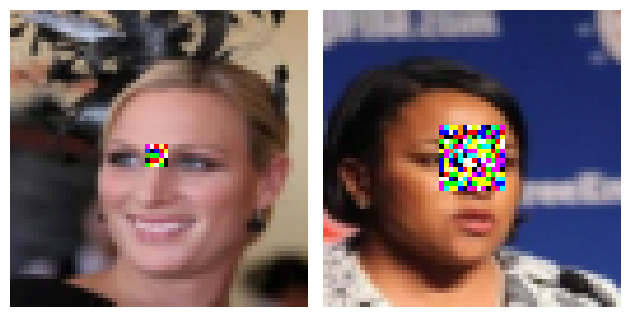

In [31]:
fig, ax = plt.subplots(1, 2)
# ax[0].set_title('Clean Image')
# # ax[1].set_title('Noisy Image')
# ax[0].imshow(images[0][idx_img,:,:,:].permute(1,2,0).cpu().numpy())
# # ax[1].imshow(y[idx_img,:,:,:].permute(1,2,0).cpu().numpy())
# ax[0].axis("off")
# ax[1].axis("off")
idx = 0
idx_img = 5
for box in [5, 14]:
    psnr = -30
    box_size = box
    noise_level = 5**2 #1e3 #0#DenoisingError(dataset_info=dataset_info, psnr=psnr).to_noise_level().variance # 0
    psnr_2 = 60
    noise_level_2 = 1e-3**2  #1**2 #1#1e-7**2 #DenoisingError(dataset_info=dataset_info, psnr=psnr_2).to_noise_level().variance # 1
    inp_mask_type = "box"
    H_deg = spatial_corr_covariance_testing(spatial_size=H, box_size=box_size, var_box=noise_level * 1, device=device, var_clean = noise_level_2 * 1, inp_mask_type=inp_mask_type, half_box_size = box_size)
    sigma_noise = 1e-3 #1e-9
    
    # y = H_deg.apply_power(images[0].cuda(), p = 1) + sigma_noise * torch.randn_like(images[0]).cuda()
    y = images[0].cuda() + H_deg.apply_power(torch.randn_like(images[0]).cuda(), p = 0.5)
    
    print(box_size)
    # fig, ax = plt.subplots(1, 5)
    # ax[0].set_title('Clean Image')
    # ax[idx].set_title(f's = {box}')
    # ax[0].imshow(images[0][idx_img,:,:,:].permute(1,2,0).cpu().numpy())
    ax[idx].imshow(y[box,:,:,:].permute(1,2,0).cpu().numpy())
    # ax[0].axis("off")
    ax[idx].axis("off")
    idx = idx + 1
plt.tight_layout()
fig.savefig("noisy_5.pdf", bbox_inches='tight', pad_inches=0.05)

20
2 1.7012541


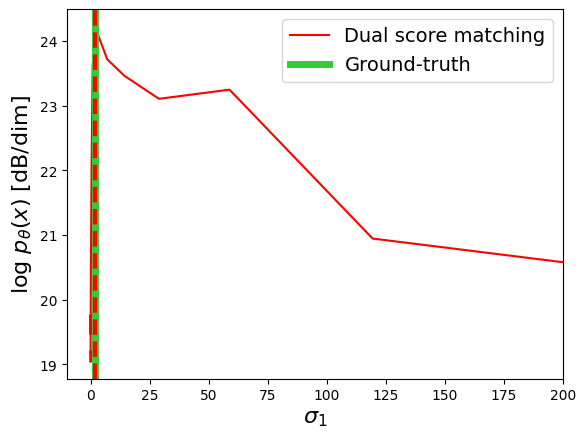

In [82]:
constant = 59882.5938

min_noise_level: NoiseLevel = NoiseLevel.from_unit(dataset_info=dataset_info, **args["min_noise_level"]) # This calls denoising error
max_noise_level: NoiseLevel = NoiseLevel.from_unit(dataset_info=dataset_info, **args["max_noise_level"])
noise_level_sampler: NoiseLevelSampler = eval(args["noise_level_sampler"])(min=min_noise_level, max=max_noise_level)

delta_box_reg = np.zeros(H)
delta_box_non_reg = np.zeros(H)
idx_img = 5 # 5 / 14
box_size = 20 #idx_img 14 / 20
ii = 0
min_energy_reg_list = []
min_energy_non_reg_list = []
for sigma in [2]: #0.1 / 2
    noise_level_2 = 1e-4  #1**2 #1#1e-7**2 #DenoisingError(dataset_info=dataset_info, psnr=psnr_2).to_noise_level().variance # 1
    inp_mask_type = "box"
    H_deg = spatial_corr_covariance_testing(spatial_size=H, box_size=box_size, var_box=sigma**2, device=device, var_clean = noise_level_2**2, inp_mask_type=inp_mask_type, half_box_size = box_size)
    
    # y = H_deg.apply_power(images[0].cuda(), p = 1) + sigma_noise * torch.randn_like(images[0]).cuda()
    y = images[0].cuda() + H_deg.apply_power(torch.randn_like(images[0]).cuda(), p = 0.5)
    
    print(box_size)
    
    num_variances = 40
    psnr_min = -30#0
    psnr_max = 90 #-35
    psnrs = torch.linspace(psnr_min, psnr_max, num_variances , device=default_ctx.device)  # (L,), steps of 7.5dB
    noise_levels = DenoisingError(dataset_info=default_ctx.dataset_info, psnr=psnrs).to_noise_level().variance  # (L,)#1e3 #0.9e-3
    
    output_reg_d2 =  torch.zeros(num_variances)
    output_non_reg_d2 =  torch.zeros(num_variances)

    sigma_idx = 0
    for sigma_inner in noise_levels:
        # H_deg_inv = [spatial_corr_covariance_testing(spatial_size=H, box_size=box_inner, var_box=noise_levels_inv, device=device, var_clean = noise_levels_2_inv, inp_mask_type=inp_mask_type, half_box_size = box_inner)]
        # y_hat = torch.clamp(y, 0, 1)
        covariance = [spatial_corr_covariance_testing(spatial_size=H, box_size=box_size, var_box=sigma_inner**2, 
                                                      device=device, var_clean = noise_level_2**2, inp_mask_type=inp_mask_type, half_box_size = box_size)]
        noise_level = NoiseLevel(variance=(noise_levels_inv))                
        input = ModelInput(noisy=y[idx_img:idx_img+1], noise_level=noise_level, covariance=covariance)
        model_output_reg = ctxs['energy-reg-d2'].model.forward(input, create_graph = False)
        model_output_non_reg = ctxs['energy-non-reg'].model.forward(input, create_graph = False)
        output_reg_d2[sigma_idx] = model_output_reg.energy  # log p(x_old)
        output_non_reg_d2[sigma_idx] = model_output_non_reg.energy  # log p(x_old)

        sigma_idx = sigma_idx + 1
        

    plt.figure(ii)
    plt.plot(noise_levels.detach().cpu().numpy(), (10.0 / np.log(10)) * ((-output_reg_d2.detach().cpu().numpy()+ constant) / CHW), '-', color = 'red', label = f'Dual score matching')
    # plt.plot(noise_levels.detach().cpu().numpy(),  (10.0 / np.log(10)) * ((-output_non_reg_d2.detach().cpu().numpy()+ constant) / CHW), '-', color = 'blue', label = f'Single score matching')
    plt.axvline(x = sigma, linewidth = 5, label = 'Ground-truth', color = 'limegreen')
    plt.axvline(x = noise_levels.detach().cpu().numpy()[np.argmin(output_reg_d2.detach().cpu().numpy())], linewidth = 3, linestyle='--', color = 'red')
    print(sigma, noise_levels.detach().cpu().numpy()[np.argmin(output_reg_d2.detach().cpu().numpy())])
    # plt.axvline(x = noise_levels.detach().cpu().numpy()[np.argmin(output_non_reg_d2.detach().cpu().numpy())], linewidth = 3, linestyle='--', color = 'blue')
    plt.legend(fontsize = 14)
    plt.xlabel(r"$\sigma_1$",fontsize = 16)
    plt.ylabel(r"log $p_{\theta}(x)$ [dB/dim]",fontsize = 16)
    ii = ii + 1
    plt.xlim([-10, 200])

    # min_energy_reg_list.append(min_energy_reg)
    # min_energy_non_reg_list.append(min_energy_non_reg)
# torch.save(delta_box, f"box_difference_{noise_levels}_mask_true.pt")
    # -12763.53

2 1.7012541


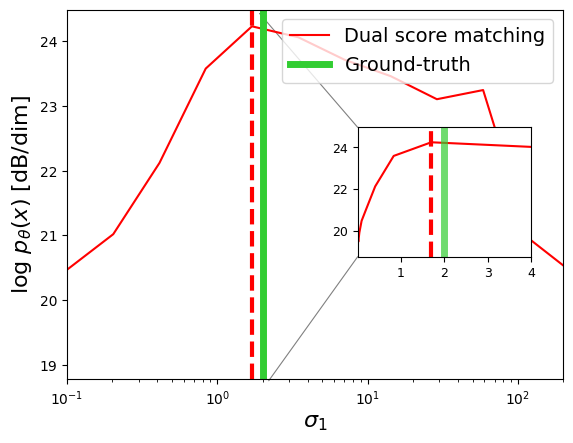

In [99]:
fig, ax = plt.subplots()

noise_np = noise_levels.detach().cpu().numpy()
y_vals = (10.0 / np.log(10)) * ((-output_reg_d2.detach().cpu().numpy() + constant) / CHW)
sigma_hat = noise_np[np.argmin(output_reg_d2.detach().cpu().numpy())]

ax.plot(noise_np, y_vals, '-', color='red', label='Dual score matching')
ax.axvline(x=sigma, linewidth=5, label='Ground-truth', color='limegreen')
ax.axvline(x=sigma_hat, linewidth=3, linestyle='--', color='red')
ax.legend(fontsize=14, loc = 1)
ax.set_xlabel(r"$\sigma_1$", fontsize=16)
ax.set_ylabel(r"log $p_{\theta}(x)$ [dB/dim]", fontsize=16)
# ax.set_xlim([-10, 200])
ax.set_xscale('log')
ax.set_xlim([0.1, 200])

# --- Inset zoom ---
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Move the inset by changing loc or using bbox_to_anchor
# loc options: 'upper right', 'upper left', 'lower right', 'lower left', etc.
# For precise positioning, use bbox_to_anchor (x, y, width, height) in axes fraction:
axins = inset_axes(ax, width="35%", height="35%",
                   bbox_to_anchor=(-0.05, -0.3, 1, 1),  # (x, y, w, h) in axes coords
                   bbox_transform=ax.transAxes,
                   loc='upper right')
axins.plot(noise_np, y_vals, '-', color='red')
axins.axvline(x=sigma, linewidth=5, color='limegreen', alpha=0.7)
axins.axvline(x=sigma_hat, linewidth=3, linestyle='--', color='red')

# Wider zoom window: sigma ± 30% of sigma (or at least ±1)
zoom_half = max(sigma * 0.3, 1.0)
x1, x2 = 0.01, 4
axins.set_xlim(x1, x2)

# Auto y-limits from data in that range
mask = (noise_np >= x1) & (noise_np <= x2)
if mask.any():
    y_min, y_max = y_vals[mask].min(), y_vals[mask].max()
    y_pad = max((y_max - y_min) * 0.15, 0.5)
    axins.set_ylim(y_min - y_pad, y_max + y_pad)

axins.tick_params(labelsize=9)
# Manual connector lines from zoom region to inset box
from matplotlib.patches import ConnectionPatch

# Line from top of zoom region to upper-left corner of inset
con1 = ConnectionPatch(
    xyA=(x1 + 1.9, y_max + 0.2), coordsA=ax.transData,   # point on main axes
    xyB=(0, 1), coordsB=axins.transAxes,               # upper-left of inset
    color="0.5", linewidth=0.8)
ax.add_artist(con1)

# Line from bottom of zoom region to lower-left corner of inset
con2 = ConnectionPatch(
    xyA=(x2 - 1.8, y_min - y_pad), coordsA=ax.transData,
    xyB=(0, 0), coordsB=axins.transAxes,
    color="0.5", linewidth=0.8)
ax.add_artist(con2)

print(sigma, sigma_hat)
ii = ii + 1

plt.savefig("blind_log_sigma2_box20.pdf")